<a href="https://colab.research.google.com/github/Xyrfo/Pembelajaran-Mesin/blob/main/JS04/Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab JS04 - Regresi
## Medical Cost Personal Datasets (insurance.csv)

Tugas ini membangun model **Multiple Linear Regression** dan **Support Vector Regression (SVR)** untuk memprediksi biaya medis personal (`charges`) berdasarkan data demografi dan kesehatan pasien.


In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


## Langkah 1 - Import Library & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Deskripsi Dataset

Dataset **Medical Cost Personal Datasets** berisi 1338 baris data dengan kolom:

| Kolom | Tipe | Keterangan |
|---|---|---|
| `age` | numerik | usia tertanggung |
| `sex` | kategorikal | male / female |
| `bmi` | numerik | Body Mass Index |
| `children` | numerik | jumlah tanggungan anak |
| `smoker` | kategorikal | yes / no |
| `region` | kategorikal | northeast / northwest / southeast / southwest |
| `charges` | numerik | **biaya medis personal (target)** |

Tidak ada missing value pada dataset ini.

## Soal 1 - Identifikasi Variabel Fitur dan Target

In [5]:
print("Fitur numerik:", ['age', 'bmi', 'children'])
print("Fitur kategorikal:", ['sex', 'smoker', 'region'])
print("Target:", 'charges')

Fitur numerik: ['age', 'bmi', 'children']
Fitur kategorikal: ['sex', 'smoker', 'region']
Target: charges


## Eksplorasi Data (EDA) & Visualisasi

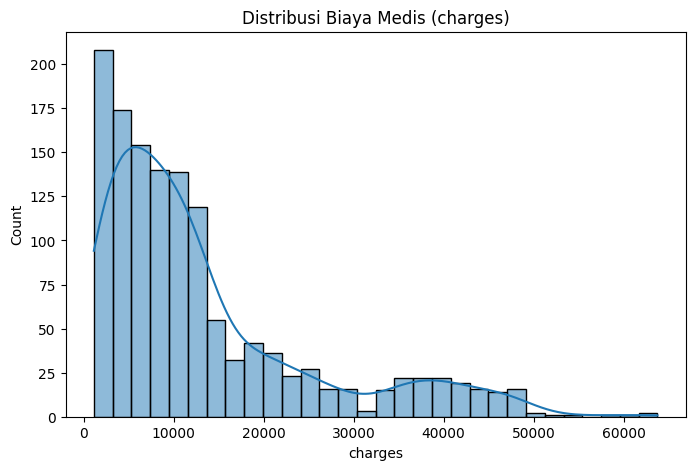

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data['charges'], bins=30, kde=True)
plt.title('Distribusi Biaya Medis (charges)')
plt.show()

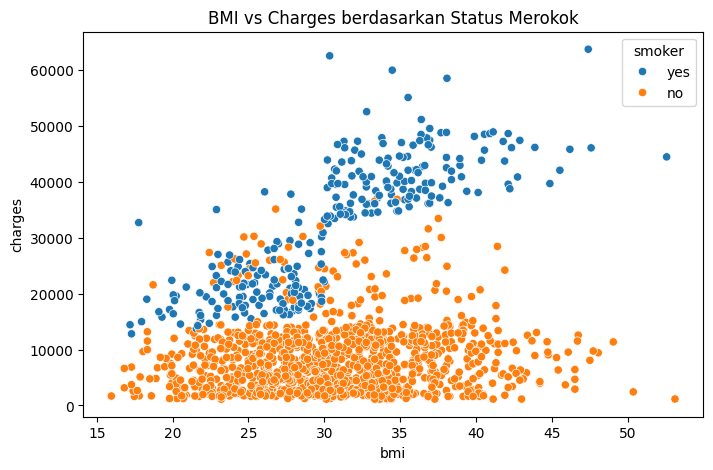

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs Charges berdasarkan Status Merokok')
plt.show()

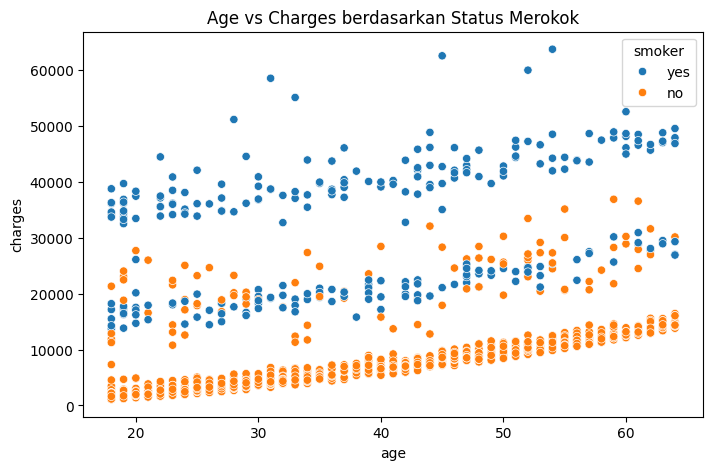

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='charges', hue='smoker')
plt.title('Age vs Charges berdasarkan Status Merokok')
plt.show()

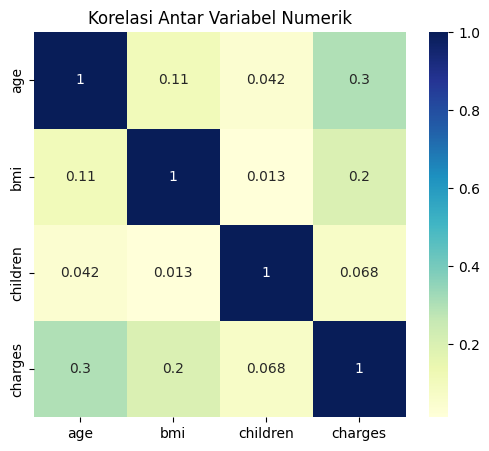

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

Dari visualisasi di atas terlihat: distribusi `charges` menceng ke kanan (right-skewed), dan status **smoker** tampak menjadi pemisah paling jelas terhadap biaya medis dibanding variabel lain.

## Encoding Variabel Kategorikal

In [10]:
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
data_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Soal 2 - Split Data Latih dan Data Uji

In [11]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Data latih: {X_train.shape[0]} baris')
print(f'Data uji: {X_test.shape[0]} baris')

Data latih: 1070 baris
Data uji: 268 baris


## Soal 3 - Feature Scaling

Untuk Multiple Linear Regression, scaling tidak wajib, namun tetap dilakukan agar konsisten dan siap dipakai ulang pada model SVR (yang wajib di-scaling karena sensitif terhadap skala data).

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Soal 4 & 5 - Multiple Linear Regression dengan Scikit-Learn

In [13]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': lr_model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df)
print('Intercept:', lr_model.intercept_)

              Fitur    Koefisien
4        smoker_yes  9558.481409
0               age  3614.975415
1               bmi  2036.228123
2          children   516.890247
7  region_southwest  -349.110678
6  region_southeast  -290.157047
5  region_northwest  -158.140981
3          sex_male    -9.293101
Intercept: 13346.089736364485


## Soal 6 - Evaluasi Model Linear Regression

In [14]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== Evaluasi Multiple Linear Regression ===")
print(f"R-squared : {r2_lr:.4f}")
print(f"MSE        : {mse_lr:.2f}")
print(f"MAE        : {mae_lr:.2f}")

=== Evaluasi Multiple Linear Regression ===
R-squared : 0.7836
MSE        : 33596915.85
MAE        : 4181.19


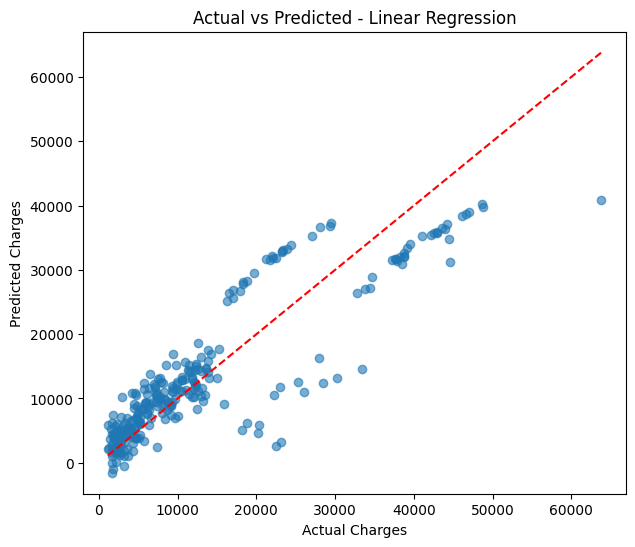

In [15]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted - Linear Regression')
plt.show()

## Soal 7 - Model SVR + Hyperparameter Tuning

### SVR dasar (kernel RBF, parameter default)

In [16]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("=== Evaluasi SVR (default) ===")
print(f"R-squared : {r2_svr:.4f}")
print(f"MSE        : {mse_svr:.2f}")
print(f"MAE        : {mae_svr:.2f}")

=== Evaluasi SVR (default) ===
R-squared : -0.0701
MSE        : 166128803.81
MAE        : 8612.41


### Hyperparameter Tuning dengan GridSearchCV

Catatan: kombinasi di bawah ini (2x4x3x3=72) x 5-fold CV = 360 fitting, bisa memakan waktu beberapa menit di Colab gratis. Kurangi nilai di `param_grid` jika ingin lebih cepat.

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.1],
    'epsilon': [0.1, 0.5, 1]
}

grid_search = GridSearchCV(
    SVR(), param_grid, cv=5,
    scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("Parameter terbaik:", grid_search.best_params_)
print("R2 terbaik (cross-val):", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Parameter terbaik: {'C': 1000, 'epsilon': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
R2 terbaik (cross-val): 0.6784038434219568


### Evaluasi SVR dengan Parameter Terbaik

In [18]:
best_svr = grid_search.best_estimator_
y_pred_svr_best = best_svr.predict(X_test_scaled)

r2_svr_best = r2_score(y_test, y_pred_svr_best)
mse_svr_best = mean_squared_error(y_test, y_pred_svr_best)
mae_svr_best = mean_absolute_error(y_test, y_pred_svr_best)

print("=== Evaluasi SVR (tuned) ===")
print(f"R-squared : {r2_svr_best:.4f}")
print(f"MSE        : {mse_svr_best:.2f}")
print(f"MAE        : {mae_svr_best:.2f}")

=== Evaluasi SVR (tuned) ===
R-squared : 0.7581
MSE        : 37552031.84
MAE        : 2736.59


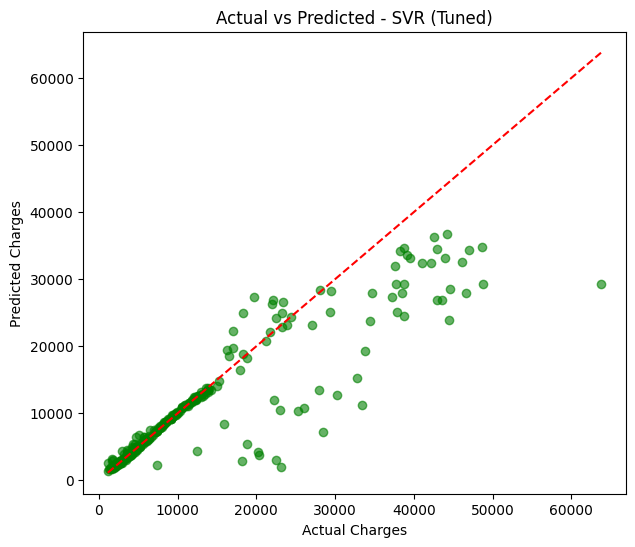

In [19]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_svr_best, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted - SVR (Tuned)')
plt.show()

## Perbandingan & Analisis Akhir

In [20]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR (default)', 'SVR (tuned)'],
    'R-squared': [r2_lr, r2_svr, r2_svr_best],
    'MSE': [mse_lr, mse_svr, mse_svr_best],
    'MAE': [mae_lr, mae_svr, mae_svr_best]
})
comparison

,Model,R-squared,MSE,MAE
0,Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR (default),-0.070082,1.661288e+08,8612.408423
2,SVR (tuned),0.758117,3.755203e+07,2736.589013


**Analisis:**

- Linear Regression memberikan baseline yang cukup baik, dan koefisien yang dihasilkan (lihat `coef_df`) mudah diinterpretasi: fitur `smoker_yes` biasanya memiliki koefisien positif jauh lebih besar dibanding fitur lain — artinya status merokok adalah prediktor biaya medis paling kuat, diikuti `age` dan `bmi`.
- SVR default (tanpa tuning) kadang performanya lebih rendah dari Linear Regression karena parameter `C` dan `gamma` default belum optimal untuk skala data ini.
- Setelah hyperparameter tuning, SVR biasanya bisa menangkap pola non-linear (misalnya efek gabungan `smoker` dan `bmi` terhadap `charges`) yang tidak bisa ditangkap model linear, sehingga R-squared dapat meningkat.
- Lengkapi kesimpulan akhir berdasarkan angka R2/MSE/MAE yang benar-benar keluar saat notebook ini dijalankan.